#Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [2]:
df = pd.read_csv("../data/telecom_customer_churn.csv")

#Display First 5 Rows

In [3]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Target,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,0,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,0,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,1,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,1,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,1,Dissatisfaction,Network reliability


#Check Dataset Shape

In [4]:
df.shape

(7043, 39)

#Check Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

#Check Missing Values

In [6]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

#Handle Missing Values

In [7]:
df["Offer"] = df["Offer"].fillna("No Offer")
df["Avg Monthly Long Distance Charges"] = df["Avg Monthly Long Distance Charges"].fillna(0)
df["Multiple Lines"] = df["Multiple Lines"].fillna("No")
df["Internet Type"] = df["Internet Type"].fillna("No Internet")
df["Avg Monthly GB Download"] = df["Avg Monthly GB Download"].fillna(0)

internet_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music"
]

for col in internet_columns:
    df[col] = df[col].fillna("No")

#Drop Leakage Columns

In [8]:
df.drop(columns=["Churn Category", "Churn Reason"], inplace=True)

#Verify

In [9]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                  

#Check Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

#Display Column Names

In [11]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Target'],
      dtype='object')

#Drop Columns

In [12]:
drop_columns = [
    "Customer ID",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude"
]

df = df.drop(columns=drop_columns)

#Check Target Variable Distribution

In [13]:
df["Target"].value_counts()

Target
0    5174
1    1869
Name: count, dtype: int64

#Drop Target Leakage Column

In [14]:
df = df.drop(columns=["Customer Status"])

#Import Required Libraries

In [15]:
import scorecardpy as sc

d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#Calculate Weight of Evidence

In [16]:
bins = sc.woebin(df, y="Target")

[INFO] creating woe binning ...


d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure pars

Binning on 7043 rows and 31 columns in 00:00:38


d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will

#Apply WOE Transformation

In [17]:
df_woe = sc.woebin_ply(df, bins)

[INFO] converting into woe values ...


#Display Information Values (IV) of Features

In [18]:
df_iv = sc.iv(df, y = "Target")
df_iv

,variable,info_value
0,Contract,1.493008
7,Number of Referrals,1.009157
11,Tenure in Months,0.919433
6,Monthly Charge,0.825033
12,Internet Type,0.566412
17,Number of Dependents,0.467914
8,Avg Monthly GB Download,0.450421
16,Offer,0.380451
27,Unlimited Data,0.375512
13,Internet Service,0.375183


#Drop Weak Features Based on IV

In [19]:
df_woe = df_woe.drop(columns=[
    "Gender_woe",
    "Phone Service_woe",
    "Multiple Lines_woe",
    "Streaming Music_woe",
    "Total Revenue_woe",
    "Streaming Movies_woe"
])

#Display Remaining WOE Features

In [20]:
df_woe.columns

Index(['Target', 'Contract_woe', 'Total Refunds_woe', 'Tenure in Months_woe',
       'Internet Service_woe', 'Paperless Billing_woe',
       'Device Protection Plan_woe', 'Premium Tech Support_woe', 'Age_woe',
       'Online Backup_woe', 'Unlimited Data_woe',
       'Avg Monthly Long Distance Charges_woe',
       'Total Long Distance Charges_woe', 'Payment Method_woe',
       'Monthly Charge_woe', 'Number of Referrals_woe',
       'Avg Monthly GB Download_woe', 'Online Security_woe',
       'Internet Type_woe', 'Total Charges_woe', 'Offer_woe',
       'Number of Dependents_woe', 'Married_woe', 'Streaming TV_woe',
       'Total Extra Data Charges_woe'],
      dtype='object')

#Import library for VIF Calculation

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent Variables

In [22]:
X = df_woe.drop(columns = ["Target"])

#Calculate VIF For Each Feature

In [23]:
vif = pd.DataFrame()

vif['features'] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range (X.shape[1])
]

vif

,features,VIF
0,Contract_woe,2.238735
1,Total Refunds_woe,1.014382
2,Tenure in Months_woe,4.149904
3,Internet Service_woe,26838.028515
4,Paperless Billing_woe,1.215801
5,Device Protection Plan_woe,1.460982
6,Premium Tech Support_woe,1.473897
7,Age_woe,1.280892
8,Online Backup_woe,1.384438
9,Unlimited Data_woe,27060.779494


#Drop Features with High VIF

In [24]:
df_woe = df_woe.drop(columns=[
    "Internet Service_woe",
    "Unlimited Data_woe",
    "Avg Monthly GB Download_woe",
    "Total Extra Data Charges_woe",
    "Internet Type_woe"
])

#Update Feature Matrix

In [25]:
X = df_woe.drop(columns = "Target")
y = df_woe["Target"]

#Split Data Into Training and Testing Sets

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state=42,
    stratify=y
)

#Import Logistic Regression and GridSearchCV

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [28]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [29]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [30]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train Logistic Regression Model

In [31]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

#Display Best Hyperparameters

In [32]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 0.1, 'solver': 'lbfgs'}
Best F1 Score : 0.690992653264504


#Predict Target Values on Test Data

In [33]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Logistic Regression Model

In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8313458262350937
Precision : 0.6897321428571429
Recall : 0.6616702355460385
F1 : 0.6754098360655738


#Display Confusion Matrix

In [36]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1155  139]
 [ 158  309]]


#Display Classification Report

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1294
           1       0.69      0.66      0.68       467

    accuracy                           0.83      1761
   macro avg       0.78      0.78      0.78      1761
weighted avg       0.83      0.83      0.83      1761



#Import Decision Tree and GridSearchCV

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [39]:
dt_model = DecisionTreeClassifier(random_state=42)

#Define Hyperparameters for Decision Tree

In [40]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [41]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

Train Decision Tree Mode

In [42]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [43]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best F1 Score : 0.6438448089264934


#Predict Target Values on Test Dataset

In [44]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Decision Tree Model

In [46]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8313458262350937
Precision : 0.7023809523809523
Recall : 0.6316916488222698
F1 : 0.6651634723788049


#Display Confusion Matrix

In [47]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1169  125]
 [ 172  295]]


#Display Classification Report

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1294
           1       0.70      0.63      0.67       467

    accuracy                           0.83      1761
   macro avg       0.79      0.77      0.78      1761
weighted avg       0.83      0.83      0.83      1761



#Feature Importance

In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                                  Feature  Importance
0                            Contract_woe    0.373851
12                Number of Referrals_woe    0.147650
6                                 Age_woe    0.078798
16               Number of Dependents_woe    0.066943
11                     Monthly Charge_woe    0.063096
2                    Tenure in Months_woe    0.054299
8   Avg Monthly Long Distance Charges_woe    0.035772
10                     Payment Method_woe    0.033409
5                Premium Tech Support_woe    0.020450
15                              Offer_woe    0.019679


#Visualize Decision Tree

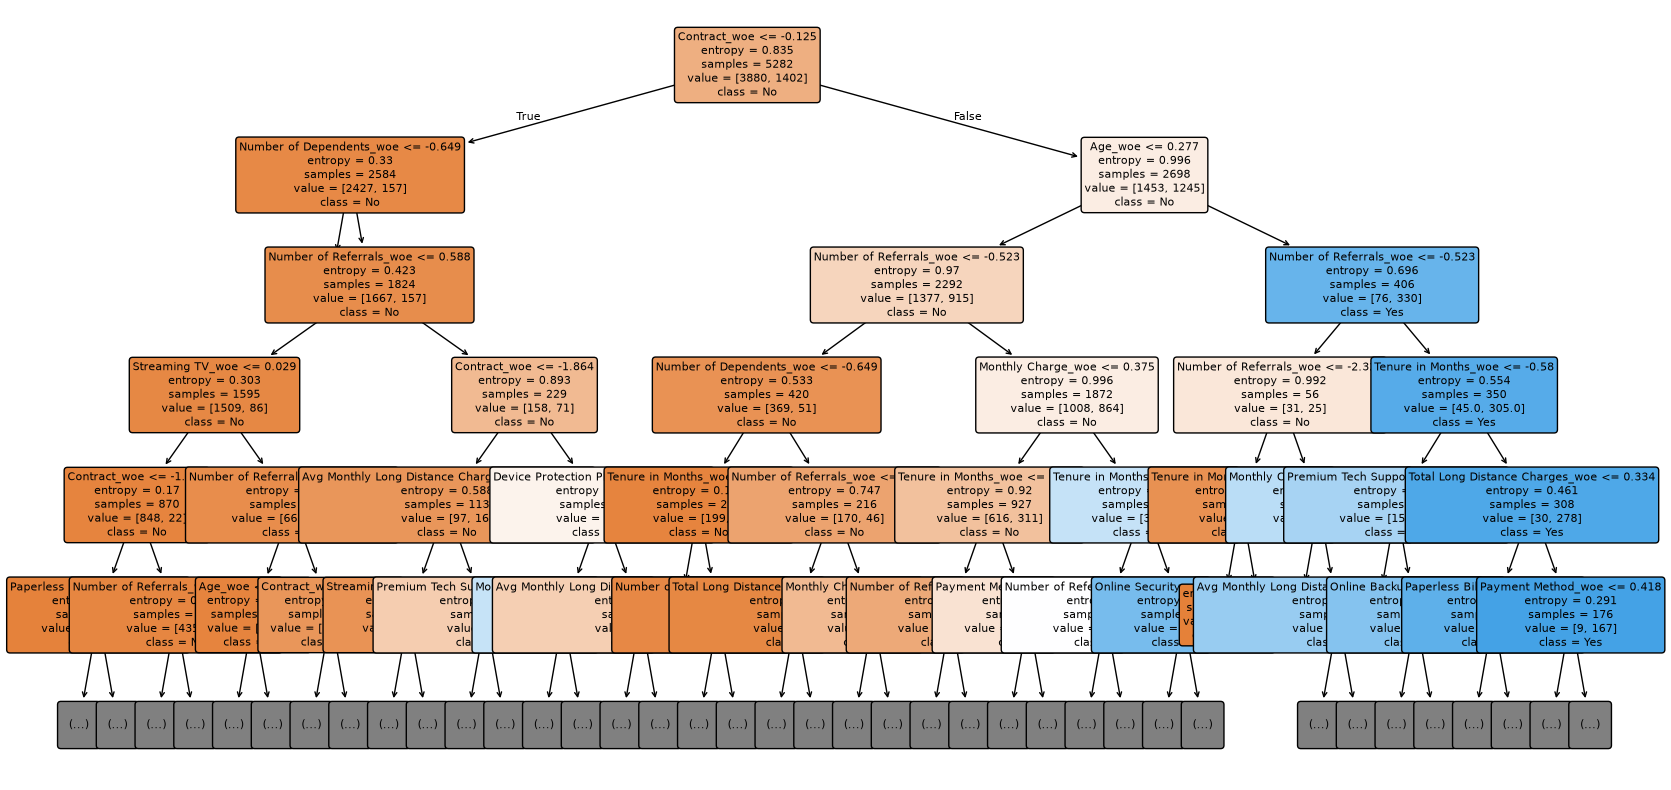

In [50]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    grid_search.best_estimator_,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8
)

plt.show()

#Import Random Forest and GridSearchCV

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#Create Random Forest Model

In [52]:
rf_model = RandomForestClassifier(random_state=42)

#Define Hyperparameter Grid

In [56]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [57]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

#Train Random Forest Model

In [58]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

#Display Best Hyperparameters

In [59]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Score : 0.6848623802586854


#Predict Target Values on Test Dataset

In [60]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Random Forest Model

In [62]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8427030096536059
Precision : 0.7339901477832512
Recall : 0.6381156316916489
F1 : 0.6827033218785796


#Display Confusion Matrix

In [63]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1186  108]
 [ 169  298]]


#Display Classification Report

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1294
           1       0.73      0.64      0.68       467

    accuracy                           0.84      1761
   macro avg       0.80      0.78      0.79      1761
weighted avg       0.84      0.84      0.84      1761



#Feature Importance

In [65]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,Contract_woe,0.239056
12,Number of Referrals_woe,0.130884
2,Tenure in Months_woe,0.104977
11,Monthly Charge_woe,0.103204
6,Age_woe,0.056003
16,Number of Dependents_woe,0.055927
10,Payment Method_woe,0.047876
9,Total Long Distance Charges_woe,0.034816
14,Total Charges_woe,0.034404
8,Avg Monthly Long Distance Charges_woe,0.031268


#Import AdaBoost and GridSearchCV

In [66]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

#Create AdaBoost Model

In [67]:
ada_model = AdaBoostClassifier(random_state=42)

#Define Hyperparameter Grid

In [69]:
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [70]:
grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

#Train AdaBoost Model

In [71]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

#Display Best Hyperparameters

In [72]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'learning_rate': 1.0, 'n_estimators': 100}
Best F1 Score : 0.6833648334245264


#Import Evaluation Metrics

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate AdaBoost Model

In [74]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8427030096536059
Precision : 0.7339901477832512
Recall : 0.6381156316916489
F1 : 0.6827033218785796


#Display Confusion Matrix

In [75]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1186  108]
 [ 169  298]]


#Display Classification Report

In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1294
           1       0.73      0.64      0.68       467

    accuracy                           0.84      1761
   macro avg       0.80      0.78      0.79      1761
weighted avg       0.84      0.84      0.84      1761

